# Multiple Linear Regression: From Math to Implementation

Welcome to this comprehensive guide on Multiple Linear Regression! This notebook will take you from the basic intuition, through the mathematical derivations, right to building a model from scratch and using `scikit-learn`.

## 1. Simple Linear Regression (A Line)

In **Simple Linear Regression**, we have one independent variable ($x$) and one dependent variable ($y$). The relationship is modeled as a **line**:
$$ y = mx + b $$

Let's visualize this.

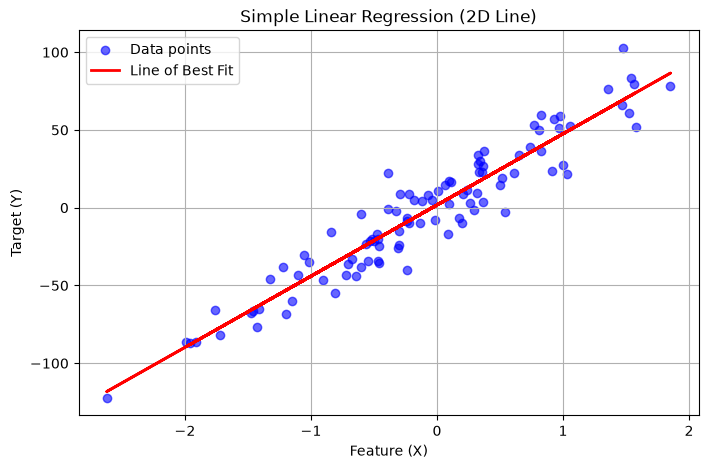

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Simple Linear Regression Data (1 Feature)
X_simple, y_simple = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(X_simple, y_simple)
y_pred_simple = lr_simple.predict(X_simple)

plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, color='blue', alpha=0.6, label='Data points')
plt.plot(X_simple, y_pred_simple, color='red', linewidth=2, label='Line of Best Fit')
plt.title('Simple Linear Regression (2D Line)')
plt.xlabel('Feature (X)')
plt.ylabel('Target (Y)')
plt.legend()
plt.grid(True)
plt.show()

## 2. Visualizing Multiple Linear Regression (3D Plane)

In **Multiple Linear Regression**, we have multiple independent variables ($x_1, x_2, \dots, x_n$). Instead of a line, we are fitting a **plane** (in 3D) or a **hyperplane** (in >3D).
$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n $$

Let's generate a toy dataset with 2 features so we can visualize how a plane fits the data points in a 3D space.

In [10]:
# 2. Multiple Linear Regression Data (2 Features)
X_multi, y_multi = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50, random_state=42)
df_multi = pd.DataFrame({'feature1': X_multi[:, 0], 'feature2': X_multi[:, 1], 'target': y_multi})

lr_multi = LinearRegression()
lr_multi.fit(X_multi, y_multi)

# Create a meshgrid for the plane
x_surf, y_surf = np.meshgrid(np.linspace(df_multi.feature1.min(), df_multi.feature1.max(), 10),
                             np.linspace(df_multi.feature2.min(), df_multi.feature2.max(), 10))
z_surf = lr_multi.intercept_ + lr_multi.coef_[0] * x_surf + lr_multi.coef_[1] * y_surf

# Plotly 3D Scatter + Plane
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=df_multi.feature1, y=df_multi.feature2, z=df_multi.target, mode='markers',
                           marker=dict(size=5, color='blue', opacity=0.8), name='Data points'))
fig.add_trace(go.Surface(x=x_surf, y=y_surf, z=z_surf, name='Regression Plane', colorscale='Viridis', opacity=0.5))
fig.update_layout(title='Multiple Linear Regression (Plane of Best Fit)',
                  scene=dict(xaxis_title='Feature 1', yaxis_title='Feature 2', zaxis_title='Target'))
fig.show()


# 3. Mathematical Derivation of Multiple Linear Regression

## 3.1 What are we actually trying to find?

In multiple linear regression, we want to find the **best values of the coefficients** of our model.

Suppose we have two input features:

* \(x_1\) = study hours
* \(x_2\) = sleep hours

and we want to predict:

* \(y\) = exam score

Our linear regression model could be:

$$
\hat y = \beta_0+\beta_1x_1+\beta_2x_2
$$

Here:

- $\hat{y}$ = predicted value
- $\beta_0$ = intercept
- $\beta_1$ = coefficient for $x_1$
- $\beta_2$ = coefficient for $x_2$

The important question is:

> **How do we find the best values of \(\beta_0,\beta_1,\beta_2\)?**

There are several ways to do this.

One famous method is **Gradient Descent**.

But there is also a direct mathematical solution called the:

# Normal Equation

$$
\boxed{\beta=(X^TX)^{-1}X^TY}
$$

Our goal is to understand exactly where this equation comes from.

---

# 3.2 First understand a single prediction

Before using matrices, let's understand the ordinary equation.

Suppose:

$$
\hat y=\beta_0+\beta_1x_1+\beta_2x_2
$$

Imagine:

$$
\beta_0=5,\qquad \beta_1=2,\qquad \beta_2=3
$$

and one student has:

$$
x_1=4,\qquad x_2=7
$$

Then:

$$
\hat y=5+2(4)+3(7)
$$

$$
\hat y=5+8+21
$$

$$
\hat y=34
$$

So the model predicts:

$$
\boxed{\hat y=34}
$$

---

# 3.3 What happens when we have many observations?

Real datasets don't contain just one observation.

Suppose we have \(m\) observations.

For example:

| Student | Study Hours \(x_1\) | Sleep Hours \(x_2\) | Actual Score \(y\) |
| ------- | ------------------: | ------------------: | -----------------: |
| 1       |                   2 |                   6 |                 40 |
| 2       |                   4 |                   7 |                 55 |
| 3       |                   6 |                   8 |                 70 |
| 4       |                   8 |                   7 |                 80 |

For every student, our model makes a prediction:

$$
\hat y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}
$$

So we get:

$$
\hat y_1,\hat y_2,\hat y_3,\ldots,\hat y_m
$$

Instead of writing every equation separately, we can use **matrices**.

This is where linear algebra becomes useful.

---

# 3.4 Representing all predictions using matrices

Our model is:

$$
\hat y=\beta_0+\beta_1x_1+\beta_2x_2
$$

We can write all \(m\) predictions simultaneously as:

$$
\hat Y=X\beta
$$

Let's understand every part.

---

## What is \(Y\)?

\(Y\) contains the actual target values.

For \(m\) observations:

$$
Y=
\begin{bmatrix}
y_1\\
y_2\\
y_3\\
\vdots\\
y_m
\end{bmatrix}
$$

Therefore \(Y\) has dimensions:

$$
\boxed{m\times1}
$$

For our example:

$$
Y=
\begin{bmatrix}
40\\
55\\
70\\
80
\end{bmatrix}
$$

---

# 3.5 What is \(X\)?

\(X\) contains all our input features.

We have two features:

$$
x_1,\quad x_2
$$

So normally we would have:

$$
X=
\begin{bmatrix}
x_{11}&x_{12}\\
x_{21}&x_{22}\\
x_{31}&x_{32}\\
\vdots&\vdots\\
x_{m1}&x_{m2}
\end{bmatrix}
$$

But there is a small problem.

Our equation contains an intercept:

$$
\beta_0
$$

We need a way to include $\beta_0$  inside matrix multiplication.

---

# 3.6 Why do we add a column of 1s?

This is one of the most important ideas.

Our model is:

$$
\hat y=\beta_0+\beta_1x_1+\beta_2x_2
$$

We can rewrite the first term as:

$$
\beta_0(1)
$$

So:

$$
\hat y=\beta_0(1)+\beta_1x_1+\beta_2x_2
$$

Now look at this:

$$
\begin{bmatrix}
1 & x_1 & x_2
\end{bmatrix}
\begin{bmatrix}
\beta_0\\
\beta_1\\
\beta_2
\end{bmatrix}
$$

Matrix multiplication gives:

$$
1(\beta_0)+x_1(\beta_1)+x_2(\beta_2)
$$

which is:

$$
\beta_0+\beta_1x_1+\beta_2x_2
$$

Exactly our original equation!

Therefore, we add a column containing only **1s**.

So our \(X\) becomes:

$$
X=
\begin{bmatrix}
1&x_{11}&x_{12}\\
1&x_{21}&x_{22}\\
1&x_{31}&x_{32}\\
\vdots&\vdots&\vdots\\
1&x_{m1}&x_{m2}
\end{bmatrix}
$$

The first column corresponds to $\beta_0$ .

---

# 3.7 The coefficient matrix $\beta$ 

Our coefficients are:

$$
\beta_0,\beta_1,\beta_2
$$

We put them into a column vector:

$$
\beta=
\begin{bmatrix}
\beta_0\\
\beta_1\\
\beta_2
\end{bmatrix}
$$

Since there are two features plus the intercept, there are:

$$
2+1=3
$$

coefficients.

In general, if there are \(n\) features:

$$
\boxed{\beta\text{ has }(n+1)\text{ elements}}
$$

---

# 3.8 Matrix dimensions

Suppose:

* \(m\) = number of observations
* \(n\) = number of features

Then:

$$
X:m\times(n+1)
$$

because we have \(n\) feature columns plus one column for the intercept.

$$
\beta:(n+1)\times1
$$

Therefore:

$$
X\beta
$$

has dimensions:

$$
[m\times(n+1)][(n+1)\times1]
$$

The inner dimensions cancel:

$$
\boxed{X\beta:m\times1}
$$

which is exactly what we want because we have \(m\) predictions.

Therefore:

$$
\boxed{\hat Y=X\beta}
$$

---

# 3.9 Example of $$X\beta$$

Suppose our data is:

| Student | Study | Sleep |
| ------- | ----: | ----: |
| 1       |     2 |     6 |
| 2       |     4 |     7 |
| 3       |     6 |     8 |
| 4       |     8 |     7 |

Then:

$$
X=
\begin{bmatrix}
1&2&6\\
1&4&7\\
1&6&8\\
1&8&7
\end{bmatrix}
$$

Suppose:

$$
\beta=
\begin{bmatrix}
5\\
2\\
3
\end{bmatrix}
$$

Then:

$$
X\beta=
\begin{bmatrix}
1&2&6\\
1&4&7\\
1&6&8\\
1&8&7
\end{bmatrix}
\begin{bmatrix}
5\\
2\\
3
\end{bmatrix}
$$

For the first row:

$$
1(5)+2(2)+6(3)=27
$$

For the second row:

$$
1(5)+4(2)+7(3)=34
$$

and so on.

Therefore:

$$
X\beta=
\begin{bmatrix}
27\\
34\\
41\\
42
\end{bmatrix}
$$

So:

$$
\boxed{\hat Y=X\beta}
$$

simply means:

> **Multiply the feature matrix by the coefficient vector to get all predictions.**

---

# 3.10 Now we need to measure how good our predictions are

Our model produces predictions:

$$
\hat Y
$$

But we already have the actual values:

$$
Y
$$

So we can calculate the error.

For one observation:

$$
e_i=y_i-\hat y_i
$$

This is called the **residual**.

For example, if:

$$
y_i=50
$$

and:

$$
\hat y_i=45
$$

then:

$$
e_i=50-45=5
$$

Our prediction was 5 below the actual value.

---

# 3.11 Residual vector

For all observations:

$$
E=Y-\hat Y
$$

Since:

$$
\hat Y=X\beta
$$

we can write:

$$
\boxed{E=Y-X\beta}
$$

This is extremely important.

It tells us:

> **Residual = Actual − Predicted**

---

# 3.12 Why can't we just minimize the sum of errors?

You might think:

$$
\text{Error}=e_1+e_2+\cdots+e_m
$$

and then minimize it.

But there is a problem.

Suppose:

$$
e_1=10
$$

and:

$$
e_2=-10
$$

Then:

$$
e_1+e_2=0
$$

It looks like there is no error!

But there actually is a significant error in both predictions.

Positive and negative errors can **cancel each other**.

So instead, we square each error.

---

# 3.13 Sum of Squared Errors

We define:

$$
SSE=e_1^2+e_2^2+\cdots+e_m^2
$$

This is called the:

$$
\boxed{\text{Sum of Squared Errors (SSE)}}
$$

Our goal is:

$$
\boxed{\text{Find }\beta\text{ that minimizes SSE}}
$$

In other words:

> We want to find the coefficients that make the total squared prediction error as small as possible.

---

# 3.14 Writing SSE using matrices

We have:

$$
E=
\begin{bmatrix}
e_1\\
e_2\\
\vdots\\
e_m
\end{bmatrix}
$$

What happens when we calculate:

$$
E^TE
$$

First:

$$
E^T=
\begin{bmatrix}
e_1&e_2&\cdots&e_m
\end{bmatrix}
$$

Therefore:

$$
E^TE=
\begin{bmatrix}
e_1&e_2&\cdots&e_m
\end{bmatrix}
\begin{bmatrix}
e_1\\
e_2\\
\vdots\\
e_m
\end{bmatrix}
$$

Matrix multiplication gives:

$$
e_1^2+e_2^2+\cdots+e_m^2
$$

Therefore:

$$
\boxed{E^TE=SSE}
$$

This is a beautiful connection:

> The matrix expression \(E^TE\) is simply the sum of squared errors.

---

# 3.15 Substitute the error equation

We already know:

$$
E=Y-X\beta
$$

Therefore:

$$
SSE=E^TE
$$

becomes:

$$
\boxed{SSE=(Y-X\beta)^T(Y-X\beta)}
$$

Now our problem is:

$$
\boxed{\text{Minimize }(Y-X\beta)^T(Y-X\beta)}
$$

with respect to \(\beta\).

---

# 3.16 Expand the expression

We have:

$$
(Y-X\beta)^T(Y-X\beta)
$$

First, use the transpose rule:

$$
(A-B)^T=A^T-B^T
$$

Therefore:

$$
(Y-X\beta)^T
=
Y^T-(X\beta)^T
$$

So:

$$
SSE=
[Y^T-(X\beta)^T](Y-X\beta)
$$

Now multiply just like ordinary algebra.

Remember:

$$
(a-b)(c-d)=ac-ad-bc+bd
$$

Therefore:

$$
SSE=
Y^TY
-Y^TX\beta
-(X\beta)^TY
+(X\beta)^TX\beta
$$

---

# 3.17 Simplifying the third term

We have:

$$
(X\beta)^TY
$$

We use the transpose rule:

$$
(AB)^T=B^TA^T
$$

Therefore:

$$
(X\beta)^T=\beta^TX^T
$$

So:

$$
(X\beta)^TY
=
\beta^TX^TY
$$

Now notice something important.

The quantity:

$$
Y^TX\beta
$$

is a scalar.

Its dimensions are:

$$
(1\times m)(m\times(n+1))(n+1\times1)
$$

which gives:

$$
1\times1
$$

A scalar is equal to its transpose.

Therefore:

$$
Y^TX\beta=\beta^TX^TY
$$

So the two middle terms are equal.

Thus:

$$
\boxed{
SSE=
Y^TY-2Y^TX\beta+\beta^TX^TX\beta
}
$$

---

# 3.18 Now comes the important part: minimizing

Our SSE is:

$$
SSE=
Y^TY-2Y^TX\beta+\beta^TX^TX\beta
$$

We want the value of \(\beta\) that makes this as small as possible.

This is exactly the same idea as ordinary calculus.

---

# 3.19 Remember how we find a minimum in calculus

Suppose:

$$
f(x)=x^2-4x+5
$$

To find its minimum, we differentiate:

$$
\frac{df}{dx}=2x-4
$$

Then set the derivative equal to zero:

$$
2x-4=0
$$

giving:

$$
x=2
$$

The same idea works here.

But instead of differentiating with respect to one number \(x\), we differentiate with respect to the **vector \(\beta\)**.

This is called a **gradient**.

---

# 3.20 Differentiate each term

We have:

$$
SSE=
Y^TY-2Y^TX\beta+\beta^TX^TX\beta
$$

Let's look at each term separately.

---

## Term 1

$$
Y^TY
$$

Notice that \(Y\) does not depend on \(\beta\).

Therefore, from the perspective of differentiating with respect to \(\beta\), it is just a constant.

So:

$$
\frac{\partial}{\partial\beta}(Y^TY)=0
$$

---

## Term 2

Consider:

$$
-2Y^TX\beta
$$

Everything except \(\beta\) is constant.

The derivative of a linear expression:

$$
a^T\beta
$$

with respect to \(\beta\) is:

$$
a
$$

Therefore:

$$
\frac{\partial}{\partial\beta}
(-2Y^TX\beta)
=
-2X^TY
$$

---

## Term 3

Now:

$$
\beta^TX^TX\beta
$$

This is a quadratic form.

For a symmetric matrix \(A\):

$$
\frac{\partial}{\partial\beta}(\beta^TA\beta)
=
2A\beta
$$

Here:

$$
A=X^TX
$$

And \(X^TX\) is symmetric because:

$$
(X^TX)^T=X^TX
$$

Therefore:

$$
\frac{\partial}{\partial\beta}
(\beta^TX^TX\beta)
=
2X^TX\beta
$$

---

# 3.21 Put all derivatives together

Therefore:

$$
\frac{\partial SSE}{\partial\beta}
=
0-2X^TY+2X^TX\beta
$$

So:

$$
\boxed{
\frac{\partial SSE}{\partial\beta}
=
-2X^TY+2X^TX\beta
}
$$

At the minimum, the gradient is zero:

$$
-2X^TY+2X^TX\beta=0
$$

---

# 3.22 Solve for \(\beta\)

Move one term to the other side:

$$
2X^TX\beta=2X^TY
$$

Divide both sides by 2:

$$
X^TX\beta=X^TY
$$

Now we want \(\beta\) by itself.

We currently have:

$$
(X^TX)\beta=X^TY
$$

This is similar to ordinary algebra.

If:

$$
3x=12
$$

we multiply both sides by:

$$
\frac13
$$

and get:

$$
x=4
$$

Here, instead of dividing by \(X^TX\), we multiply by its inverse.

The inverse of \(X^TX\) is:

$$
(X^TX)^{-1}
$$

Therefore:

$$
(X^TX)^{-1}(X^TX)\beta
=
(X^TX)^{-1}X^TY
$$

Since:

$$
A^{-1}A=I
$$

we get:

$$
I\beta=(X^TX)^{-1}X^TY
$$

and:

$$
\boxed{\beta=(X^TX)^{-1}X^TY}
$$

This is the **Normal Equation**.

---

# 3.23 What does the Normal Equation actually do?

The equation:

$$
\boxed{\beta=(X^TX)^{-1}X^TY}
$$

takes your dataset and directly calculates the coefficients that minimize the **sum of squared errors**.

You don't have to manually try:

$$
\beta_0=1,\beta_1=2,\ldots
$$

and you don't need to iteratively update the coefficients like Gradient Descent.

The mathematics gives us a direct solution.

---

# 3.24 Let's see the complete chain

The entire derivation can be remembered as a sequence:

### Step 1 — Model

$$
\boxed{\hat Y=X\beta}
$$

### Step 2 — Error

$$
\boxed{E=Y-\hat Y}
$$

Therefore:

$$
\boxed{E=Y-X\beta}
$$

### Step 3 — Squared error

$$
\boxed{SSE=E^TE}
$$

Therefore:

$$
\boxed{SSE=(Y-X\beta)^T(Y-X\beta)}
$$

### Step 4 — Expand

$$
\boxed{
SSE=Y^TY-2Y^TX\beta+\beta^TX^TX\beta
}
$$

### Step 5 — Differentiate

$$
\boxed{
\frac{\partial SSE}{\partial\beta}
=
-2X^TY+2X^TX\beta
}
$$

### Step 6 — Set derivative to zero

$$
-2X^TY+2X^TX\beta=0
$$

### Step 7 — Rearrange

$$
X^TX\beta=X^TY
$$

### Step 8 — Multiply by inverse

$$
\boxed{
\beta=(X^TX)^{-1}X^TY
}
$$

That's the entire Normal Equation derivation.

---

# 3.25 Why is it called the "Normal Equation"?

When we set:

$$
X^TX\beta=X^TY
$$

we are obtaining the condition that the residual vector is **orthogonal/perpendicular to the columns of \(X\)**.

Remember:

$$
E=Y-X\beta
$$

At the optimal solution:

$$
X^TE=0
$$

Substitute \(E\):

$$
X^T(Y-X\beta)=0
$$

Expand:

$$
X^TY-X^TX\beta=0
$$

Therefore:

$$
X^TX\beta=X^TY
$$

This equation is called the **normal equation** because the residual is normal (perpendicular) to the column space of \(X\).

You don't need to memorize this geometric interpretation initially, but it becomes very useful later when studying linear algebra and least squares.

---

# 3.26 A very important intuition

Imagine your model is trying to fit a line to data.

You have:

$$
\text{Actual values}
$$

and:

$$
\text{Predicted values}
$$

The difference is:

$$
\text{Residual}
$$

We want the coefficients that make the overall residual as small as possible.

So the logic is:

$$
\boxed{
\text{Choose }\beta
\rightarrow
\text{make predictions}
\rightarrow
\text{calculate errors}
\rightarrow
\text{square errors}
\rightarrow
\text{minimize total error}
}
$$

The Normal Equation is simply the mathematical shortcut that gives us the optimal \(\beta\).

---

# 3.27 What happens in Python?

Once we understand the mathematics, the implementation becomes surprisingly short.

Conceptually:

```python
beta = np.linalg.inv(X.T @ X) @ X.T @ y
```

This is directly:

$$
\boxed{\beta=(X^TX)^{-1}X^TY}
$$

where:

```text
X.T
```

means:

$$
X^T
$$

and:

```text
@
```

means matrix multiplication.

So:

```python
X.T @ X
```

means:

$$
X^TX
$$

and:

```python
np.linalg.inv(X.T @ X)
```

means:

$$
(X^TX)^{-1}
$$

---

# 3.28 One important practical point

Although the mathematical formula is:

$$
\beta=(X^TX)^{-1}X^TY
$$

in actual numerical programming, we generally **shouldn't explicitly calculate the inverse** using:

```python
np.linalg.inv()
```

A numerically safer approach is usually:

```python
beta = np.linalg.solve(X.T @ X, X.T @ y)
```

This solves:

$$
X^TX\beta=X^TY
$$

directly.

Even better, libraries such as NumPy can use more numerically stable least-squares methods:

```python
beta = np.linalg.lstsq(X, y, rcond=None)[0]
```

But for **learning the mathematics**, the inverse form is extremely useful because it makes the derivation clear:

$$
\boxed{\beta=(X^TX)^{-1}X^TY}
$$

---

# 3.29 The most important things to remember

If you're learning this for the first time, **don't try to memorize the entire derivation word-for-word**.

Understand these relationships:

$$
\boxed{\hat Y=X\beta}
$$

**Prediction**

↓

$$
\boxed{E=Y-X\beta}
$$

**Error**

↓

$$
\boxed{SSE=E^TE}
$$

**Total squared error**

↓

$$
\boxed{
SSE=(Y-X\beta)^T(Y-X\beta)
}
$$

↓

Expand:

$$
\boxed{
Y^TY-2Y^TX\beta+\beta^TX^TX\beta
}
$$

↓

Differentiate:

$$
\boxed{
-2X^TY+2X^TX\beta=0
}
$$

↓

Rearrange:

$$
\boxed{
X^TX\beta=X^TY
}
$$

↓

Solve:

$$
\boxed{
\beta=(X^TX)^{-1}X^TY
}
$$

### The one-line memory trick

Think:

> **Prediction → Error → Square → Minimize → Normal Equation**

or mathematically:

$$
\boxed{
X\beta
\rightarrow
Y-X\beta
\rightarrow
(Y-X\beta)^T(Y-X\beta)
\rightarrow
\frac{\partial}{\partial\beta}=0
\rightarrow
\beta=(X^TX)^{-1}X^TY
}
$$

That is the core idea behind **Ordinary Least Squares Multiple Linear Regression**.



## 4. Implementation from Scratch

Let's build our own Multiple Linear Regression class using the formula we just derived: $\beta = (X^T X)^{-1} X^T Y$.

In [11]:
class MyMultipleRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X_train, y_train):
        # 1. Add a column of 1s to X_train for the intercept (beta_0)
        X_train_with_intercept = np.insert(X_train, 0, 1, axis=1)
        
        # 2. Calculate beta = (X^T * X)^-1 * X^T * Y
        # np.linalg.inv computes the inverse of a matrix
        # .dot() is for matrix multiplication
        betas = np.linalg.inv(X_train_with_intercept.T.dot(X_train_with_intercept)).dot(X_train_with_intercept.T).dot(y_train)
        
        # 3. Extract intercept and coefficients
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
        
    def predict(self, X_test):
        # y = beta_0 + beta_1*x_1 + beta_2*x_2 ...
        return self.intercept_ + np.dot(X_test, self.coef_)

## 5. Testing our Custom Model vs Scikit-Learn

In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# 1. Train our custom model
my_lr = MyMultipleRegression()
my_lr.fit(X_train, y_train)
y_pred_my = my_lr.predict(X_test)

print("--- Custom Model ---")
print("Intercept (Beta_0):", my_lr.intercept_)
print("Coefficients (Beta_1, Beta_2):", my_lr.coef_)

# 2. Train scikit-learn model
sk_lr = LinearRegression()
sk_lr.fit(X_train, y_train)
y_pred_sk = sk_lr.predict(X_test)

print("\n--- Scikit-Learn Model ---")
print("Intercept:", sk_lr.intercept_)
print("Coefficients:", sk_lr.coef_)

# Check if predictions are identical
print("\nAre predictions the same?", np.allclose(y_pred_my, y_pred_sk))

--- Custom Model ---
Intercept (Beta_0): 0.3297740182160094
Coefficients (Beta_1, Beta_2): [80.60169788 72.03894822]

--- Scikit-Learn Model ---
Intercept: 0.32977401821600694
Coefficients: [80.60169788 72.03894822]

Are predictions the same? True


## 6. Why do we need Gradient Descent?

If the formula $\beta = (X^T X)^{-1} X^T Y$ gives us the exact answer, why do we use algorithms like **Gradient Descent**?

Look at the matrix inversion: $(X^T X)^{-1}$. 
The time complexity of inverting an $n \times n$ matrix is roughly $\mathcal{O}(n^3)$. 
If you have a dataset with $100,000$ features, inverting that matrix is computationally impossible for most computers. 

For small datasets (like 100 or 1000 features), OLS (Ordinary Least Squares - the Normal Equation) is fast and perfect. But for large scale machine learning, the high time complexity forces us to use iterative optimization algorithms like Gradient Descent to estimate the weights efficiently!